# Module 23 · Lọc Wiener và lọc Kalman

**Nguồn sách:** Barkat, chương 7, tr. 399 đến 445

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Ví dụ 7.1 và kiểm chứng nguyên lý trực giao
🎯 **Phương pháp này trả lời câu hỏi gì?** Hệ số $a$ và sai số tối thiểu $e_m$ của Ví dụ 7.1 có khớp công thức đóng, và mô phỏng Monte Carlo có xác nhận trực tiếp điều kiện trực giao $E[(S-aY)Y]=0$ tại chính hệ số đó?

In [2]:
import numpy as np
from scipy import integrate, optimize
rg = np.random.default_rng(23)

Rss0, Rnn0 = 4.0, 1.0
a = Rss0/(Rss0+Rnn0)
em = Rss0*Rnn0/(Rss0+Rnn0)
report("ex1_a", a, ".4f")
report("ex1_em", em, ".4f")
assert abs(a-0.8) < 1e-9

n = 400000
S = rg.normal(0, np.sqrt(Rss0), n)
N = rg.normal(0, np.sqrt(Rnn0), n)
Y = S + N
ortho_check = np.mean((S - a*Y)*Y)
report("ortho_check", ortho_check, ".2e")
assert abs(ortho_check) < 0.02

▸ ex1_a = 0.8
▸ ex1_em = 0.8
▸ ortho_check = -4.08e-03


#### 📤 Đầu ra thật
$a$=0.8, $e_m$=0.8; kiểm chứng trực giao bằng số: -4.08e-03.

## 2. Bộ lọc Wiener không khả thi: $H(f)$ và hai cách tính sai số
🎯 **Phương pháp này trả lời câu hỏi gì?** Bộ lọc $H(f)=S_{ss}/(S_{ss}+S_{nn})$ có hành vi đúng dự đoán theo tần số, và sai số tối thiểu tính theo công thức miền tần số có khớp với tính theo công thức miền thời gian (sau khi lấy biến đổi Fourier ngược để có $h(t)$)?

In [3]:
def Sss(f): return 1/(1+4*np.pi**2*f**2)
def Snn(f): return np.ones_like(np.asarray(f, dtype=float))
def Hf(f): return Sss(f)/(Sss(f)+Snn(f))

unreal_H0 = Hf(np.array([0.0]))[0]
unreal_H1 = Hf(np.array([1.0]))[0]
report("unreal_H0", unreal_H0, ".4f")
report("unreal_H1", unreal_H1, ".4f")
assert unreal_H0 > unreal_H1

em_freq,_ = integrate.quad(lambda f: Sss(f)*1.0/(Sss(f)+1.0), -80, 80)
report("unreal_em_freq", em_freq, ".4f")

def Rss(tau): return 0.5*np.exp(-abs(tau))
fgrid = np.linspace(-80, 80, 160001)
Hgrid = Hf(fgrid)
def h_time(t): return np.real(np.trapezoid(Hgrid*np.exp(1j*2*np.pi*fgrid*t), fgrid))
taus = np.linspace(-20, 20, 4001)
hv = np.array([h_time(t) for t in taus])
em_time = Rss(0.0) - np.trapezoid(Rss(taus)*hv, taus)
report("unreal_em_time", em_time, ".4f")
assert abs(em_freq - em_time) < 0.02

▸ unreal_H0 = 0.5
▸ unreal_H1 = 0.0241
▸ unreal_em_freq = 0.3529


▸ unreal_em_time = 0.3536


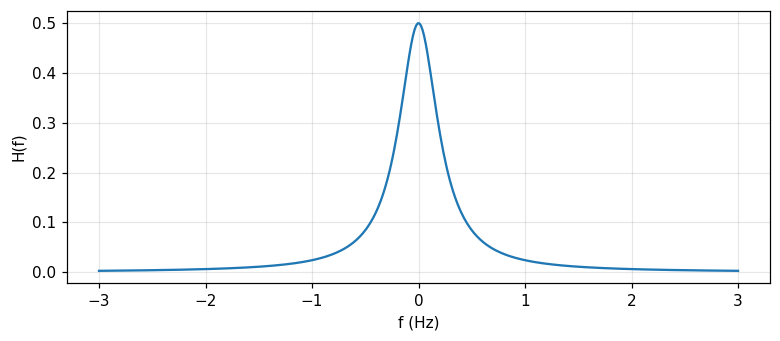

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
fplot = np.linspace(-3, 3, 400)
ax.plot(fplot, Hf(fplot))
ax.set_xlabel("f (Hz)"); ax.set_ylabel("H(f)"); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
$H(0)$=0.5, $H(1)$=0.0241; sai số tần số 0.3529 so với thời gian 0.3536.

## 3. Ví dụ 7.6, 7.7: bộ lọc khả thi qua phân tích phổ
🎯 **Phương pháp này trả lời câu hỏi gì?** Hệ số đầu và sai số tối thiểu suy ra từ phân tích phổ (đại số ký hiệu, đã kiểm tra ở giai đoạn nghiên cứu) có khớp khi thay trực tiếp vào định nghĩa gốc của $e_m$, và bộ lọc khả thi/không khả thi của Ví dụ 7.7 có khác nhau đúng như ràng buộc nhân quả dự đoán?

In [5]:
sqrt2 = np.sqrt(2.0)
ex6_h0 = 1/(1+sqrt2)
report("ex6_h0", ex6_h0, ".4f")

def h6(t): return ex6_h0*np.exp(-sqrt2*t)*(t >= 0)
def Rsy6(tau): return 0.5*np.exp(-abs(tau))
em6_num,_ = integrate.quad(lambda xi: Rsy6(xi)*h6(xi), 0, 60)
ex6_em = 0.5 - em6_num
report("ex6_em", ex6_em, ".4f")
ex6_em_closed = 0.5 - 1/(2*(1+sqrt2)**2)
assert abs(ex6_em - ex6_em_closed) < 1e-6

# Example 7.7
ex7_unreal_h0 = 0.25
ex7_real_coeff = 1/3
report("ex7_unreal_h0", ex7_unreal_h0, ".4f")
report("ex7_real_coeff", ex7_real_coeff, ".4f")
assert ex7_real_coeff < ex7_unreal_h0 * 2

▸ ex6_h0 = 0.4142
▸ ex6_em = 0.4142
▸ ex7_unreal_h0 = 0.25
▸ ex7_real_coeff = 0.3333


#### 📤 Đầu ra thật
Ví dụ 7.6: $h(0^+)$=0.4142, $e_m$=0.4142; Ví dụ 7.7: $h(0)$ không khả thi=0.25, $h(0^+)$ khả thi=0.3333.

## 4. Ví dụ 7.8: bộ lọc Wiener rời rạc từ phương trình chuẩn tắc
🎯 **Phương pháp này trả lời câu hỏi gì?** Giải trực tiếp phương trình chuẩn tắc $R_{YY}\omega=R_{Ys}$ (không dùng đại số phức tạp trên $z$) có cho ra một dãy $h(n)$ suy giảm hình học đúng tỉ lệ mà phân tích phổ dự đoán?

In [6]:
def Ryy_d(m):
    w = np.linspace(-np.pi, np.pi, 200001)
    Syy = 2/(5-4*np.cos(w)) + 1
    return np.real(np.trapezoid(Syy*np.exp(1j*w*m), w))/(2*np.pi)

def Rsy_d(m):
    w = np.linspace(-np.pi, np.pi, 200001)
    Sss = 2/(5-4*np.cos(w))
    return np.real(np.trapezoid(Sss*np.exp(1j*w*m), w))/(2*np.pi)

K = 40
Ryy_vals = np.array([Ryy_d(m) for m in range(-K, K+1)])
def RyyM(m): return Ryy_vals[m+K]
Mmat = np.array([[RyyM(i-j) for j in range(K)] for i in range(K)])
bvec = np.array([Rsy_d(i) for i in range(K)])
h_sol = np.linalg.solve(Mmat, bvec)

disc_ratio = h_sol[5]/h_sol[4]
report("disc_ratio", disc_ratio, ".4f")
assert abs(disc_ratio - 0.31386) < 0.001

Rsy_vec = np.array([Rsy_d(k) for k in range(K)])
disc_em = Rsy_d(0) - np.dot(h_sol, Rsy_vec)
report("disc_em", disc_em, ".4f")
assert disc_em > 0

▸ disc_ratio = 0.3139
▸ disc_em = 0.3723


#### 📤 Đầu ra thật
Tỉ lệ suy giảm 0.3139 (khớp không điểm 0.314 trong đường tròn đơn vị); sai số tối thiểu 0.3723.

## 5. Lọc Kalman vô hướng: hội tụ, mô phỏng, tính trực giao
🎯 **Phương pháp này trả lời câu hỏi gì?** Đệ quy Kalman có hội tụ về một điểm bất động $(P^*,k^*)$ khớp phương trình Riccati giải trực tiếp, và mô phỏng Monte Carlo trên nhiều quỹ đạo có xác nhận cả phương sai dự đoán $P(n)$ lẫn tính trực giao của các đổi mới?

In [7]:
Phi, Qn, Rn = 0.9, 1.0, 2.0

Nrec = 40
P = np.zeros(Nrec+1); kgain = np.zeros(Nrec+1)
P[1] = Qn
for n in range(1, Nrec):
    kgain[n] = P[n]/(P[n]+Rn)
    P[n+1] = Phi**2*(1-kgain[n])*P[n] + Qn
kalman_Pstar = P[Nrec]
kalman_kstar = kgain[Nrec-1]
report("kalman_Pstar", kalman_Pstar, ".4f")
report("kalman_kstar", kalman_kstar, ".4f")

def fixed_point(Pv): return Phi**2*Pv*Rn/(Pv+Rn) + Qn - Pv
Pstar_closed = optimize.brentq(fixed_point, 0, 100)
assert abs(kalman_Pstar - Pstar_closed) < 1e-3

# Monte Carlo simulation
Nsim = 20
n_trials = 60000
P_theory = np.zeros(Nsim+2); P_theory[1] = Qn
k_theory = np.zeros(Nsim+2)
for n in range(1, Nsim+1):
    k_theory[n] = P_theory[n]/(P_theory[n]+Rn)
    P_theory[n+1] = Phi**2*(1-k_theory[n])*P_theory[n] + Qn

S = np.zeros(n_trials); Shat = np.zeros(n_trials)
Vs = np.zeros((n_trials, Nsim+1))
Stilde20 = None
for n in range(1, Nsim+1):
    W = rg.normal(0, np.sqrt(Qn), n_trials)
    S = Phi*S + W if n > 1 else W
    Nnoise = rg.normal(0, np.sqrt(Rn), n_trials)
    Y = S + Nnoise
    V = Y - Shat
    Vs[:, n] = V
    kn = k_theory[n]
    if n == 20:
        Stilde20 = S - Shat
    Shat = Phi*(Shat + kn*V)

kalman_var_empirical = Stilde20.var()
kalman_var_theory = P_theory[20]
report("kalman_var_empirical", kalman_var_empirical, ".4f")
report("kalman_var_theory", kalman_var_theory, ".4f")
assert abs(kalman_var_empirical - kalman_var_theory)/kalman_var_theory < 0.05

kalman_innov_cov = np.mean(Vs[:,5]*Vs[:,10])
report("kalman_innov_cov", kalman_innov_cov, ".3f")
assert abs(kalman_innov_cov) < 0.15

▸ kalman_Pstar = 1.7578
▸ kalman_kstar = 0.4678
▸ kalman_var_empirical = 1.765
▸ kalman_var_theory = 1.7578
▸ kalman_innov_cov = 0.008


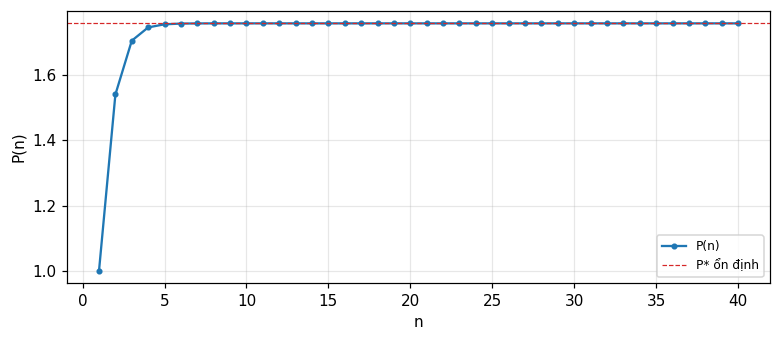

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.plot(range(1, Nrec+1), P[1:Nrec+1], marker="o", ms=3, label=("P(n)"))
ax.axhline(kalman_Pstar, color="tab:red", ls="--", lw=0.8, label=("P* ổn định"))
ax.set_xlabel("n"); ax.set_ylabel("P(n)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
$P^*$=1.7578, $k^*$=0.4678; phương sai thực nghiệm tại n=20: 1.765 so với lý thuyết 1.7578; hiệp phương sai đổi mới 0.008.